# Matplotlib

## Fonctionnement général de Matplotlib

### Comment se construit un graph sur Matplotlib

Il y a plusieurs éléments à prendre en considération lorsqu'on construit un graphique sur Matplotlib. Le schéma ci-dessous devrait pouvoir vous aider à y voir plus clair.

![](https://matplotlib.org/3.1.1/_images/anatomy.png)


Principalement, vous devez retenir les éléments hiérarchiques suivants :

- La **Figure** : Une *figure* est l'ensemble du cadre à l'intérieur duquel est contenu votre ou vos graphiques. Vous pourrez définir la taille de votre *figure*, le nombre graphique à l'intérieur, etc.
  
- Les **Axes** : Ceci correspond à un graphique à l'intérieur de votre *figure*

![](https://miro.medium.com/max/848/1*Fk80UWElsZI6f_poAv_7cQ.png)

- Les **Axis** : Faites attention à ne pas confondre avec l'élément du dessus. Les *Axis* correspondent à l'abscisse et l'ordonnée de chacun des graphiques (ou *Axes*).
  
- **Artist** : Il est possible que vous voyez ce terme dans la documentation de [Matplotlib](https://matplotlib.org/3.1.1/tutorials/introductory/usage.html#interactive-example). Cela désigne l'ensemble des éléments dans le graphique (incluant *Figure*, *Axes*, *Axis*)

### Les inputs d'un graphique sur Matplotlib

Pour le moment, Matplotlib préfère recevoir des objets **numpy** en tant qu'input de graphique.

Notamment, les objets **Pandas** peuvent entrainer des comportements inattendus. Nous vous conseillons donc de les transformer via :

```python
X = dataset.values
```

Pour la suite nous aurons donc besoin des librairies *numpy* et *matplotlib* (plus précisément, le module *pyplot* de *matplotlib*). Nous allons donc les importer :

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Les différents types de graphiques

Voici une liste de graphiques à connaître qui vont vous être utiles pour votre *EDA*

## Les line plots

### Quelle utilisation ?

Les *line plots* sont extrêmement utiles pour les données de types Séries Temporelles.

### Le code

Pour pouvoir créer un *line plot*, il vous suffira d'utiliser :

```python
plt.plot()
```

## Lineplot : plt.plot()

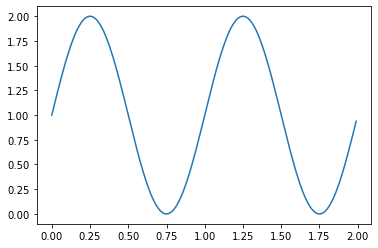

In [2]:
# Création de données sinusoïdales
t = np.arange(0.0, 2.0, 0.01)
s = 1 + np.sin(2 * np.pi * t)

# Création du LinePlot
plt.plot(t, s)
plt.show()

### Quelques paramètres utiles pour changer l'aspect de la figure

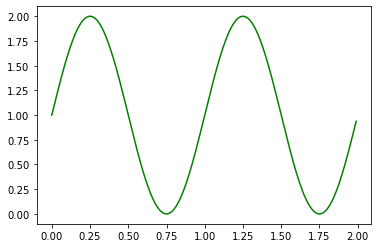

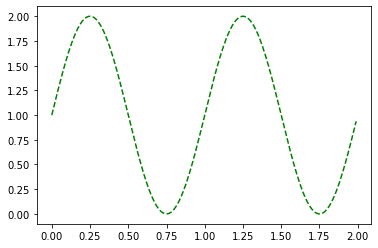

In [3]:
# Changer la couleur
plt.plot(t, s, color="green")
plt.show()

# Changer le style de ligne
plt.plot(t, s, color="green", linestyle="--")
plt.show()

Vous avez le choix de plusieurs styles de lignes dont voici quelques exemples :

```python
linestyle: {'-', '--', '-.', ':', '', ...}
```

## Superposer plusieurs *line plots* dans la même figure
Pour superposer plusieurs *line plots* dans la même figure, il suffit d'appeler plusieurs fois la fonction `plt.plot()` avant de faire un uniqure `plt.show()` :

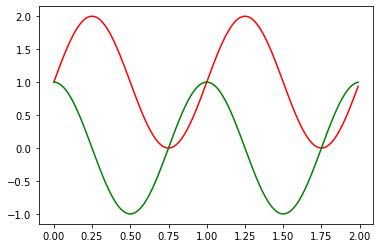

In [4]:
# Création de données sinusoïdales
t = np.arange(0.0, 2.0, 0.01)
s1 = 1 + np.sin(2 * np.pi * t)
s2 = np.cos(2 * np.pi * t)

# Création de la figure
plt.plot(t, s1, color='red')
plt.plot(t, s2, color='green')
plt.show()

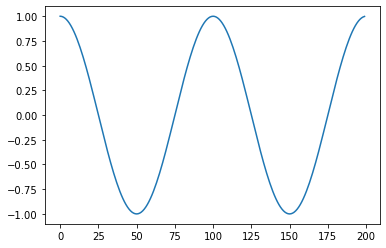

In [5]:
plt.plot(s2)

### Pour aller plus loin avec les *line plots*

Pour aller au-delà des fonctionnalités montrées dans cette démo, vous pouvez vous référer à documentation officielle de matplotlib. La doc d'une fonction est accessible directement depuis un *jupyter notebook* en utilisant le symbole `?` :

In [6]:
plt.plot?

## Les bar charts

### Quelle utilisation ?

Les *bar charts* sont plutôt utilisés pour observer des éléments de différents groupes, par exemple le taux de réussite au bac selon les différentes villes de France.

Un *bar chart* se fait grâce à ```plt.bar()```

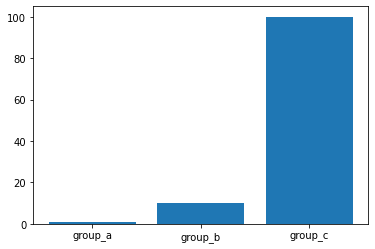

In [7]:
# Création d'une liste de données
names = ['group_a', 'group_b', 'group_c']
values = [1, 10, 100]

# Création du barplot
plt.bar(names, values)
plt.show()

### Faire des *Stacked Bar Plot*

Vous pouvez empiler des *bar plot* via le paramètre ```bottom```. Pour cela, vous devrez créer deux lignes de bar plot de la façon suivante :

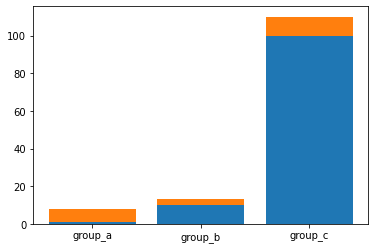

In [8]:
# Stacked bar plot

# Création des données
names = ['group_a', 'group_b', 'group_c']
values_1 = [1, 10, 100]
values_2 = [7, 3, 10]

# Création des barplots
plt.bar(names, values_1)
plt.bar(names, values_2, bottom=values_1)
plt.show()

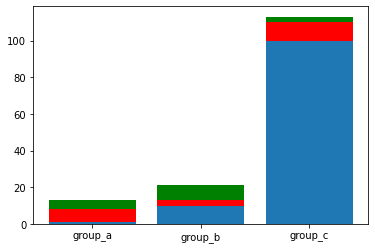

In [9]:
# Stacked bar plot

# Création des données
names = ['group_a', 'group_b', 'group_c']
values_1 = np.array([1, 10, 100])
values_2 = np.array([7, 3, 10])
values_3 = np.array([5, 8, 3])

# Création des barplots
plt.bar(names, values_1)
plt.bar(names, values_2, bottom=values_1, color='red')
plt.bar(names, values_3, bottom=values_2 + values_1, color='green')
plt.show()

### Choisir l'orientation des barres

Vous pouvez choisir l'orientation des barres en utilisant cette fois : ```plt.barh``` au lieu de ```plt.bar```. La méthode fonctionne de la même manière que celle plus haut.

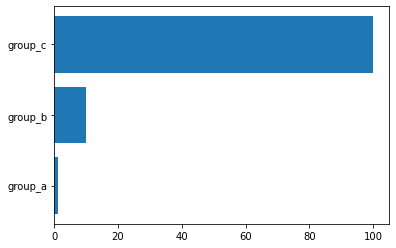

In [10]:
# Création de données aléatoires
names = ['group_a', 'group_b', 'group_c']
values = [1, 10, 100]

# Create barplot
plt.barh(names, values_1)
plt.show()

## Les histogrammes

### Quelle utilisation ?

Les *histogrammes* sont très utiles pour montrer une distribution. Par exemple, la répartition des revenus en fonction de l'âge.

### Le code

Le moyen de faire un histogramme est via ```plt.hist```

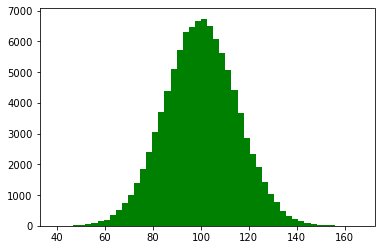

In [11]:
# Distribution d'une variable aléatoire x

# Création d'une liste de 10.000 valeurs tirées aléatoirement selon une loi Normale
mu, sigma = 100, 15
x = mu + sigma * np.random.randn(100000)

# Création de l'histogramme
plt.hist(x, 50, facecolor='g')
plt.show()

Nous précision à l'avance dans le graphique le nombre de bins : En l'occurence 50.

### Quelques paramètres intéressants

#### Density

L'histogramme, comme nous l'avons dit plus haut est souvent utilisé pour visualiser une distribution. Plutôt que de connaître des valeurs brutes, on essaie plutôt de déterminer une distribution de probabilité.

Pour cela, il suffit de mettre l'argument ```density=True```

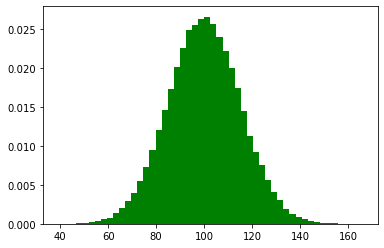

In [12]:
# Création de l'histogramme
plt.hist(x, 50, facecolor='g', density=True)
plt.show()

## Les pie charts

### Quelle utilisation ?

Les *pie charts* sont utiles lorsque vous souhaitez montrer la répartition d'éléments faisant partie d'un tout. Typiquement, vous voulez connaître la répartition des hommes et des femmes en France.

### Le code

Il faudra cette fois utiliser ```plt.pie``` pour créer son pie chart.

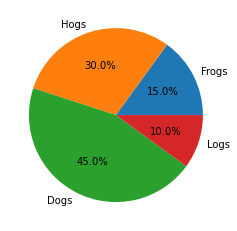

In [13]:
# Pie chart (chaque élément sera affiché dans le sens inverse des aiguilles d'une montre)
labels = 'Frogs', 'Hogs', 'Dogs', 'Logs'
sizes = [15, 30, 45, 10]

plt.pie(sizes, labels=labels, autopct='%1.1f%%')

plt.show()

### Quelques paramètres utiles

#### Explode

Parfois, il est utile de faire ressortir une *part du camembert* ou, en termes plus scientifiques, de faire ressortir un élément.

Pour cela, on peut utiliser l'argument `explode`. Celui-ci prend un tuple de la taille du nombre d'éléments dans le pie-chart. La valeur que vous mettrez dans chacun des indices du tuples correspondra à la distance à laquelle se trouvera l'élément du centre du pie chart.

Voici un exemple :

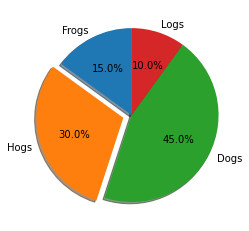

In [15]:
# Explode

# Pie chart (chaque élément sera affiché dans le sens inverse des aiguilles d'une montre)
labels = 'Frogs', 'Hogs', 'Dogs', 'Logs'
sizes = [15, 30, 45, 10]
# Ici, on souhaite mettre la catégorie "Hogs" en avant.
explode = (0, 0.1, 0, 0)

plt.pie(sizes, explode=explode,labels=labels, autopct='%1.1f%%',
        shadow=True, startangle=90)
plt.show()

## Les box plots

### Quelle utilisation ?

Les *box plots* sont très utiles lorsque vous souhaitez connaître la distribution d'une variable catégorique. Par exemple, vous souhaitez connaître la répartition des notes à un contrôle de Maths.

### Le code

Pour faire un *boxplot*, vous pouvez utiliser ```plt.boxplot```

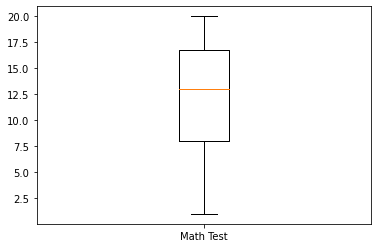

In [17]:
# Création de données aléatoires (en l'occurence des notes à un test de maths)
math_test = np.random.randint(1, 20 + 1, 30)

# Création du boxplot
plt.boxplot(math_test, labels=['Math Test'])
plt.show()

In [18]:
plt.boxplot?

NB : Si vous lancez le code, vous n'aurez peut-être pas le même *boxplot*, ceci est normal puisque les données sont générées aléatoirement via `np.random.randint()`

**Comment interpréter un boxplot**

Un *boxplot* est utile pour voir où se trouve la majorité de vos données. Par exemple, dans le graphique du dessus, on sait que la majorité des élèves ont eu entre 10 et 17.5. La grosse boite représente en fait *l'écart interquartile* c'est à dire 50% du dataset se trouve dans cette boite.

La ligne orange représente la *médiane*. Autrement dit, la moitié du dataset a eu une note inférieure à 12 et l'autre moitié a eu une note supérieure à 12.

Le reste du *boxplot* représente des valeurs minimum et maximum.

Il est aussi possible que les graphiques vous donne des *points en dehors du boxplot* qui sont cette fois des *outliers*

### Quelques paramètres utiles

#### Définir une limite d'outliers

Si vous le souhaitez, vous pouvez utiliser l'argument `whis` dont la valeur que vous allez insérer va déterminer les valeurs au delà desquelles, les éléments de votre échantillons seront considérés comme des outliers.

Le calcul se fait de la manière suivante :

```python
Upper_bound = Q3 + whis*IQR
Lower_bound = Q1 - whis*IQR
```

Où IQR est l'écart interquartile (Q3-Q1)

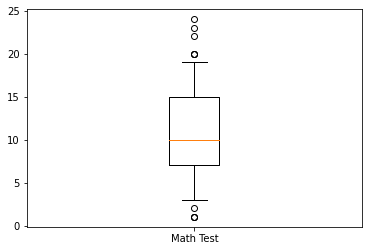

In [19]:
# Changer le seuil pour les outliers

# Création de données aléatoires (en l'occurence des notes à un test de maths)
math_test = np.random.randint(1, 20 + 1, 30)

# Ajout de valeurs aberrantes
math_test = np.append(math_test, np.array([22, 23, 24]))

# Creation du boxplot
plt.boxplot(math_test,
            whis=0.6,
           labels=['Math Test'])
plt.show()

#### Ajouter la moyenne dans votre box plot

Visualiser la moyenne sur votre graphique est plutôt utile lorsque vous souhaitez la comparer à la médiane et en voir l'écart. Il vous suffira d'ajouter les arguments :

- `showmeans=True`
- `meanline=True`

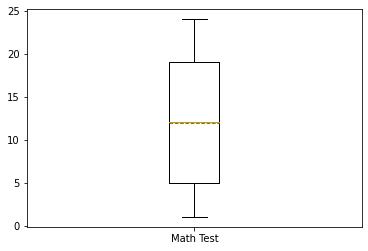

In [20]:
# Ajouter la moyenne

# Création de données aléatoires (en l'occurence des notes à un test de maths)
math_test = np.random.randint(1, 20 + 1, 30)

# Ajout de valeurs aberrantes
math_test = np.append(math_test, np.array([22, 23, 24]))

# Creation du boxplot
plt.boxplot(math_test,
            whis=0.6,
            showmeans=True,
            meanline=True,
            labels=['Math Test'])
plt.show()

## Les scatter plots

### Quelle utilisation ?

Les *scatter plots* sont utilisés pour voir la relalation entre deux variables. Vous allez donc souvent les employer en Machine Learning.

### Le code

Vous aurez simplement à utiliser `plt.scatter` pour créer un *scatter plot*.

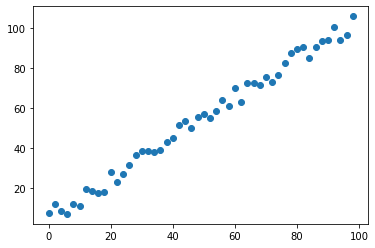

In [21]:
# Création de données aléatoires
x = np.arange(0.0, 100.0, 2.0)  # np.arange permet de créer des suites de nombre régulièrement espacés (ici : entre 0 et 100 par pas de 2)
y = x + np.random.rand(*x.shape) * 10.0  # Ici, on crée un relation approximativement linéaire entre x et y

# Création du scatter plot
plt.scatter(x, y)
plt.show()

### Quelques paramètres utiles

#### Changer la taille de vos points

Parfois, vous voudrez peut être avoir des points plus gros en fonction de certaines conditions. Vous pouvez le faire grâce à l'argument ```s```

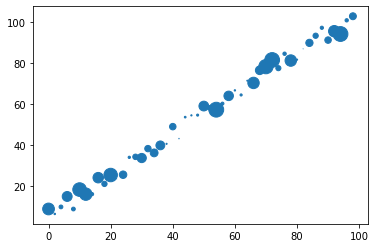

In [22]:
# Changer la taille des points

# Création de données aléatoires
x = np.arange(0.0, 100.0, 2.0)
# np.arange permet de créer des suites de nombre régulièrement espacés (ici : entre 0 et 100 par pas de 2)
y = x + np.random.rand(*x.shape) * 10.0 
# Ici, on crée un relation approximativement linéaire entre x et y

# Ajout de différentes tailles pour chacun des points
area = (15 * np.random.rand(50)) ** 2  

# Création du scatter plot
plt.scatter(x, y, s=area)
plt.show()

#### Changer la couleur de vos points

Vous pouvez aussi changer la couleur de vos points en fonction de certaines conditions via l'argument ```c```

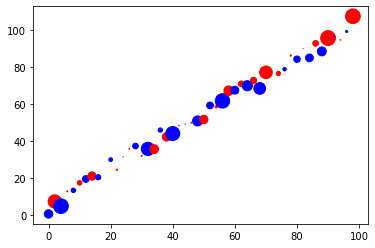

In [23]:
# Change the color of the markers

# Création de données aléatoires
x = np.arange(0.0, 100.0, 2.0)
# np.arange permet de créer des suites de nombre régulièrement espacés (ici : entre 0 et 100 par pas de 2)
y = x + np.random.rand(*x.shape) * 10.0
# Ici, on crée un relation approximativement linéaire entre x et y

# Ajout de différentes tailles pour chacun des points
area = (15 * np.random.rand(50)) ** 2  

# Ajout d'une séquence de couleurs
c = ["b", "r"] * 25

# Creation of the scatter plot
plt.scatter(x, y, s=area, c=c)
plt.show()

## Personnaliser les graphiques

Nous avons vu les principaux types de graphiques que vous pouviez faire avec Matplotlib mais nous n'avons pas vu comment les personnaliser.

Il est important en effet de pouvoir ajouter des titres, du texte et autres éléments de ce genre à l'intérieur de vos graphiques. C'est donc le thème de cette partie.

### Ajouter des titres

Pour ajouter un titre, il vous suffit de mettre ```plt.title()```

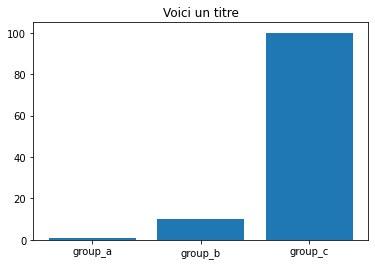

In [24]:
# Add titles

# Création de données aléatoires
names = ['group_a', 'group_b', 'group_c']
values = [1, 10, 100]

# Création du Barplot
plt.bar(names, values)
plt.title("Voici un titre")  # L'ajout du titre se fait ici
plt.show()

### Ajouter une légende

Vous pouvez ajouter des légendes via ```plt.legend()```

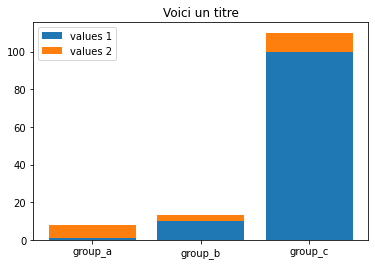

In [25]:
# Ajouter une légende

# Création des données
names = ['group_a', 'group_b', 'group_c']
values_1 = [1, 10, 100]
values_2 = [7, 3, 10]

# Création des barplots
plt.bar(names, values_1)
plt.bar(names, values_2, bottom=values_1)
plt.title("Voici un titre")  # Ajout du titre
plt.legend(["values 1", "values 2"])  # Ajout de la légende
plt.show()


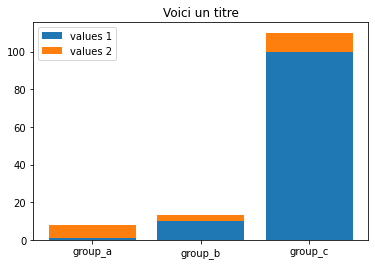

In [26]:
# Ajouter une légende (autre méthode)

# Création des données
names = ['group_a', 'group_b', 'group_c']
values_1 = [1, 10, 100]
values_2 = [7, 3, 10]

# Création des barplots
plt.bar(names, values_1, label="values 1")
plt.bar(names, values_2, bottom=values_1, label="values 2")
plt.title("Voici un titre")  # Ajout du titre
plt.legend()  # Ajout de la légende
plt.show()


### Ajouter des labels aux abscisses & ordonnées

On peut bien sûr donner des noms aux axes du graphique via ```plt.xlabel``` ou ```plt.ylabels```

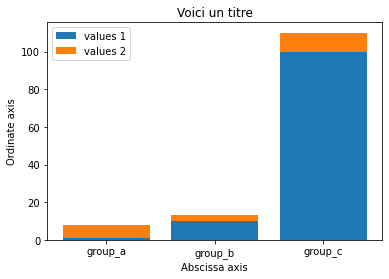

In [27]:
# Ajout de labels aux abcisses & ordonnées

# Création des données
names = ['group_a', 'group_b', 'group_c']
values_1 = [1, 10, 100]
values_2 = [7, 3, 10]

# Création des barplots
plt.bar(names, values_1)
plt.bar(names, values_2, bottom=values_1)
plt.title("Voici un titre")  # Ajout du titre
plt.legend(["values 1", "values 2"])  # Ajout de la légende
plt.xlabel("Abscissa axis")  # Label pour l'abscisse
plt.ylabel("Ordinate axis")  # Label pour l'ordonnée
plt.show()

### Ajouter du texte dans votre graphique

Parfois, il faut ajouter du texte à l'intérieur de vos graphiques pour pouvoir donner plus de visibilité au lecteur sur les valeurs exactes. Pour cela, on peut utiliser ```plt.text```

Cette méthode fonctionne de la façon suivante :

- Vous spécifiez les coordonnées du texte sur les axes des abscisses puis des ordonnées
- Vous spécifiez le texte que vous souhaitez mettre

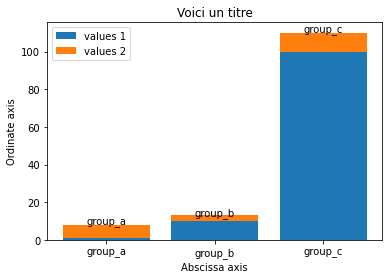

In [28]:
# Ajout de texte

# Création des données
names = ['group_a', 'group_b', 'group_c']
values_1 = [1, 10, 100]
values_2 = [7, 3, 10]

# Création des barplots
plt.bar(names, values_1)
plt.bar(names, values_2, bottom=values_1)
plt.title("Voici un titre")  # Ajout du titre
plt.legend(["values 1", "values 2"])  # Ajout de la légende
plt.xlabel("Abscissa axis")  # Label pour l'abscisse
plt.ylabel("Ordinate axis")  # Label pour l'ordonnée
# Ajout de texte au-dessus des barres
plt.text(names[0], values_1[0] + values_2[0], names[0], horizontalalignment='center')
plt.text(names[1], values_1[1] + values_2[1], names[1], horizontalalignment='center')
plt.text(names[2], values_1[2] + values_2[2], names[2], horizontalalignment='center')
plt.show()

### Agrandir votre graphique

Souvent, vous aurez besoin d'agrandir la taille de votre graphique, vous pouvez le faire via ```plt.figure(figsize=(height, width))```

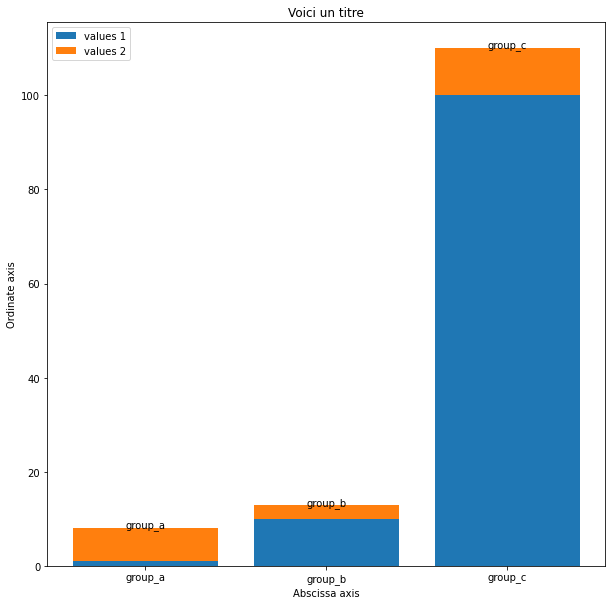

In [29]:
# Agrandir un graphique

# Création des données
names = ['group_a', 'group_b', 'group_c']
values_1 = [1, 10, 100]
values_2 = [7, 3, 10]

# Création du Barplot
# Changement de la taille de la figure
plt.figure(figsize=(10, 10))
plt.bar(names, values_1)
plt.bar(names, values_2, bottom=values_1)
plt.title("Voici un titre")  # Ajout du titre
plt.legend(["values 1", "values 2"])  # Ajout de la légende
plt.xlabel("Abscissa axis")  # Label pour l'abscisse
plt.ylabel("Ordinate axis")  # Label pour l'ordonnée
# Ajout de texte au-dessus des barres
plt.text(0, values_1[0] + values_2[0], names[0], horizontalalignment='center')
plt.text(1, values_1[1] + values_2[1], names[1], horizontalalignment='center')
plt.text(2, values_1[2] + values_2[2], names[2], horizontalalignment='center')
plt.show()

### Combiner plusieurs sous-figures dans une même figure

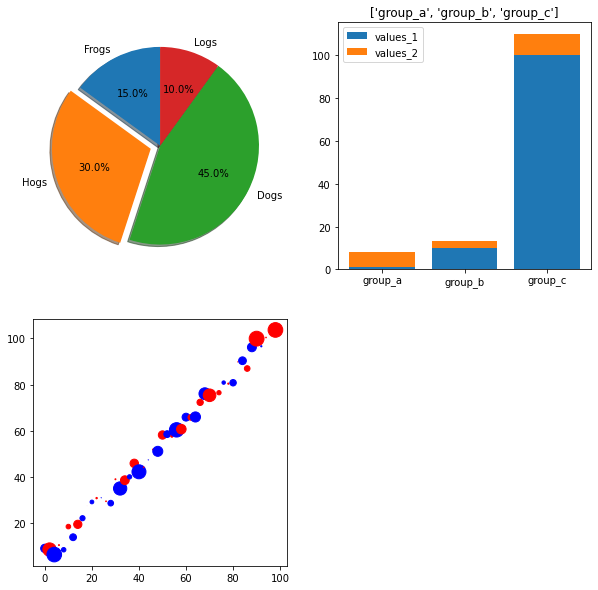

In [30]:
# Création des données pour le Pie Chart
labels = 'Frogs', 'Hogs', 'Dogs', 'Logs'
sizes = [15, 30, 45, 10]
explode = (0, 0.1, 0, 0)

# Création des données pour le Bar Chart
names = ['group_a', 'group_b', 'group_c']
values_1 = [1, 10, 100]
values_2 = [7, 3, 10]

# Création des données pour le Scatter Plot
x = np.arange(0.0, 100.0, 2.0)
# np.arange permet de créer des suites de nombre régulièrement espacés (ici : entre 0 et 100 par pas de 2)
y = x + np.random.rand(*x.shape) * 10.0
# Ici, on crée un relation approximativement linéaire entre x et y

# Création de la figure via plt.subplot()
plt.figure(figsize=(10, 10))

## Création du Pie Chart
plt.subplot(221)  # on demande 2x2 sous-figures, le Pie Chart sera en position 1
plt.pie(sizes, explode=explode,labels=labels, autopct='%1.1f%%',
        shadow=True, startangle=90)

## Création du Bar Chart
plt.subplot(222)  # on demande 2x2 sous-figures, le Bar Chart sera en position 2
plt.bar(names, values_1)
plt.bar(names, values_2, bottom=values_1)
plt.title(names)  # Create title
plt.legend(["values_1", "values_2"])  # Create legends

# Création du Scatter Plot
plt.subplot(223)  # on demande 2x2 sous-figures, le Scatter Plot sera en position 3
plt.scatter(x, y, s=area, c=c)

plt.show()